# Importy

In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
import os
import torch.nn as nn

# Za 4 punkty

### Opis środowiska Lunar Lander

...

### Opis algorytmu Proximal Policy Optimization (PPO)

...

### Stałe

In [9]:
env_id = "LunarLander-v3"
total_timesteps = 100000
n_runs = 10

### Zestawy parametrów

In [10]:
hyperparams_sets = [
    {"name": "Set 1 (Default)", "lr": 3e-4, "batch_size": 64},
    {"name": "Set 2 (Fast/Large)", "lr": 1e-3, "batch_size": 128},
    {"name": "Set 3 (Slow/Small)", "lr": 5e-5, "batch_size": 32}
]

### Trening dla różnych zestawów hiperparametrów

In [11]:
log_dir = "./logs"
os.makedirs(log_dir, exist_ok=True)

results = {}
execution_times = []

for hp in hyperparams_sets:
    print(f"Starting: {hp['name']}")
    all_runs_rewards = []

    for run in range(n_runs):
        env = gym.make(env_id, continuous=True)

        run_log_dir = f"{log_dir}/{hp['name']}_run_{run}"
        os.makedirs(run_log_dir, exist_ok=True)
        env = Monitor(env, run_log_dir)

        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=hp["lr"],
            batch_size=hp["batch_size"],
            seed=run,
            verbose=1,
            device="cuda"
        )

        start_time = time.time()
        model.learn(total_timesteps=total_timesteps)
        model.save(f"ppo_lunar_{hp['name']}_run_{run}")
        end_time = time.time()

        execution_times.append((end_time - start_time) / total_timesteps)

        x, y = ts2xy(load_results(run_log_dir), "timesteps")

        eval_steps = np.linspace(0, total_timesteps, 100)
        y_interp = np.interp(eval_steps, x, y)
        all_runs_rewards.append(y_interp)

        env.close()

    results[hp["name"]] = {
        "steps": eval_steps,
        "mean": np.mean(all_runs_rewards, axis=0),
        "std": np.std(all_runs_rewards, axis=0)
    }

Starting: Set 1 (Default)
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 109      |
|    ep_rew_mean     | -304     |
| time/              |          |
|    fps             | 698      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 106          |
|    ep_rew_mean          | -281         |
| time/                   |              |
|    fps                  | 560          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0024529463 |
|    clip_fraction        | 0.0145       |
|    clip_range           | 0.2          |
|    entropy_loss     

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 119      |
|    ep_rew_mean     | -273     |
| time/              |          |
|    fps             | 629      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 113         |
|    ep_rew_mean          | -228        |
| time/                   |             |
|    fps                  | 553         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005456317 |
|    clip_fraction        | 0.0384      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | -5.72e-05   |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 112      |
|    ep_rew_mean     | -315     |
| time/              |          |
|    fps             | 737      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 119         |
|    ep_rew_mean          | -299        |
| time/                   |             |
|    fps                  | 605         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004128326 |
|    clip_fraction        | 0.0199      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.85       |
|    explained_variance   | 0.000421    |
|    learning_rate        | 0.

...

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 111      |
|    ep_rew_mean     | -333     |
| time/              |          |
|    fps             | 772      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 114          |
|    ep_rew_mean          | -261         |
| time/                   |              |
|    fps                  | 494          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0036028067 |
|    clip_fraction        | 0.0124       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.00534      |
|    learning_r

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 118      |
|    ep_rew_mean     | -287     |
| time/              |          |
|    fps             | 788      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 121         |
|    ep_rew_mean          | -273        |
| time/                   |             |
|    fps                  | 458         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004430149 |
|    clip_fraction        | 0.0184      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | -0.00324    |
|    learning_rate        | 5e

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Wizualizacja procesu uczenia

Average time per timestep: 0.002243 seconds


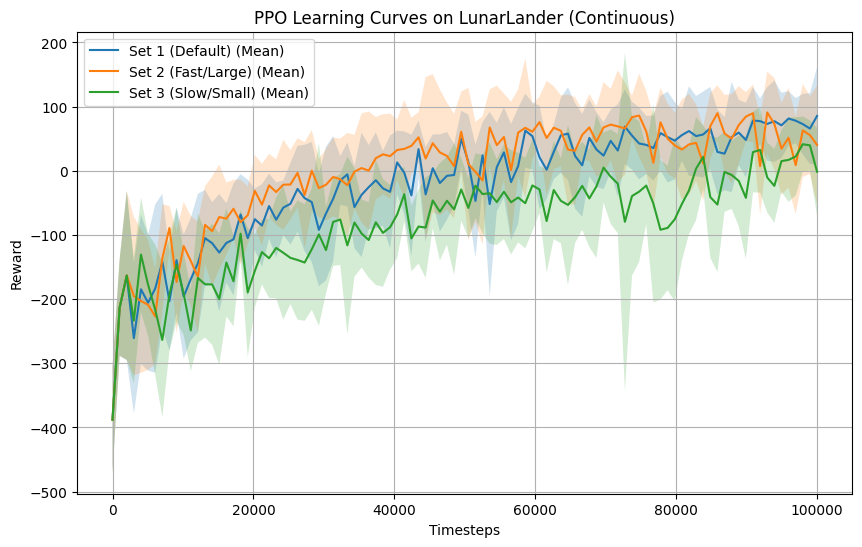

In [12]:
avg_step_time = np.mean(execution_times)
print(f"Average time per timestep: {avg_step_time:.6f} seconds")

plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data["steps"], data["mean"], label=f"{name} (Mean)")
    plt.fill_between(
        data["steps"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("PPO Learning Curves on LunarLander (Continuous)")
plt.legend()
plt.grid(True)
plt.savefig("learning_curves.png")
plt.show()

# Za 6 punktów

### Uczenie różnych architektur

In [ ]:
log_dir = "./logs_architecture"
os.makedirs(log_dir, exist_ok=True)

architectures = [
    {
        "name": "Architecture_256x256_ReLU",
        "policy_kwargs": dict(
            net_arch=dict(pi=[256, 256], vf=[256, 256]),
            activation_fn=nn.ReLU
        )
    },
    {
        "name": "Architecture_256x256_Tanh",
        "policy_kwargs": dict(
            net_arch=dict(pi=[256, 256], vf=[256, 256]),
            activation_fn=nn.Tanh
        )
    }
]

results = {}
execution_times = []

for arch in architectures:
    print(f"Starting architecture test: {arch['name']}")
    all_runs_rewards = []
    
    for run in range(n_runs):
        print(f"  - Run {run}/{n_runs}")
        env = gym.make(env_id, continuous=True)
        
        run_log_dir = f"{log_dir}/{arch['name']}_run_{run}"
        os.makedirs(run_log_dir, exist_ok=True)
        env = Monitor(env, os.path.join(run_log_dir, "monitor.csv"))
        
        model = PPO(
            "MlpPolicy", 
            env, 
            learning_rate=0.0003,
            batch_size=64,
            seed=run, 
            policy_kwargs=arch["policy_kwargs"], 
            verbose=0,
            device="cuda"
        )
        
        start_time = time.time()
        model.learn(total_timesteps=total_timesteps)
        model.save(f"ppo_lunar_{arch['name']}_run_{run}")
        end_time = time.time()
        
        execution_times.append((end_time - start_time) / total_timesteps)
        
        x, y = ts2xy(load_results(run_log_dir), "timesteps")
        eval_steps = np.linspace(0, total_timesteps, 100)
        y_interp = np.interp(eval_steps, x, y)
        all_runs_rewards.append(y_interp)
        
        env.close()
        
    results[arch["name"]] = {
        "steps": eval_steps,
        "mean": np.mean(all_runs_rewards, axis=0),
        "std": np.std(all_runs_rewards, axis=0)
    }

### Wizualizacja

In [ ]:
print(f"Average time per timestep: {np.mean(execution_times):.6f} seconds")

plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data["steps"], data["mean"], label=f"{name} (Mean)")
    plt.fill_between(data["steps"], data["mean"] - data["std"], data["mean"] + data["std"], alpha=0.15)

plt.title("PPO Architecture Comparison on LunarLander (Continuous)")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.savefig("architecture_comparison.png")
plt.show()